In [2]:
import pandas as pd
from sqlalchemy import create_engine

# reuse the same connection details you used to push area_landmark_correlation earlier
engine = create_engine("postgresql://postgres:@localhost:5433/real_estate_data")

query = """
SELECT
    area_name,
    year,
    SUM(actual_worth_capped) AS total_value,
    AVG(actual_worth_capped) AS avg_value,
    COUNT(*) AS txn_count
FROM transactions
WHERE trans_group = 'Sales'
    AND year BETWEEN 2000 AND 2025
GROUP BY area_name, year
ORDER BY area_name, year;
"""

df = pd.read_sql(query, engine)
df.head()

,area_name,year,total_value,avg_value,txn_count
0,Abu Hail,2000,64270393.95,1.890306e+06,34
1,Abu Hail,2001,18216439.00,6.281531e+05,29
2,Abu Hail,2002,32448949.00,6.904032e+05,47
3,Abu Hail,2003,40121510.00,7.715675e+05,52
4,Abu Hail,2004,99317345.00,1.398836e+06,71


In [3]:
df.shape

(3542, 5)

In [4]:
df.groupby('area_name')['year'].count().describe()

count    238.000000
mean      14.882353
std        8.998056
min        1.000000
25%        6.000000
50%       17.000000
75%       24.000000
max       26.000000
Name: year, dtype: float64

In [5]:
years_per_area = df.groupby('area_name')['year'].count()
qualifying_areas = years_per_area[years_per_area >= 10].index

df_filtered = df[df['area_name'].isin(qualifying_areas)].copy()

print(f"Areas before filter: {df['area_name'].nunique()}")
print(f"Areas after filter: {df_filtered['area_name'].nunique()}")

Areas before filter: 238
Areas after filter: 165


In [6]:
area_features = df_filtered.groupby('area_name').agg(
    total_value=('total_value', 'sum'),
    txn_count=('txn_count', 'sum')
).reset_index()

area_features.head()

,area_name,total_value,txn_count
0,AL QUSAIS,2.104173e+09,133
1,AL TWAR FIFTH,5.146400e+08,128
2,Abu Hail,1.388435e+09,856
3,Al Aweer First,3.710293e+08,77
4,Al Aweer Second,5.531563e+08,92


In [7]:
area_features['avg_deal_size'] = area_features['total_value'] / area_features['txn_count']
area_features.head()

,area_name,total_value,txn_count,avg_deal_size
0,AL QUSAIS,2.104173e+09,133,1.582085e+07
1,AL TWAR FIFTH,5.146400e+08,128,4.020625e+06
2,Abu Hail,1.388435e+09,856,1.622004e+06
3,Al Aweer First,3.710293e+08,77,4.818562e+06
4,Al Aweer Second,5.531563e+08,92,6.012568e+06


In [8]:
# average value in the early window per area
early_window = df_filtered[df_filtered['year'].between(2000, 2002)].groupby('area_name')['avg_value'].mean().rename('early_avg')

# average value in the late window per area
late_window = df_filtered[df_filtered['year'].between(2023, 2025)].groupby('area_name')['avg_value'].mean().rename('late_avg')

# combine and compute growth
growth_a = pd.concat([early_window, late_window], axis=1)
growth_a['growth_a_pct'] = (growth_a['late_avg'] / growth_a['early_avg'] - 1) * 100

growth_a.head()

,early_avg,late_avg,growth_a_pct
area_name,,,
AL QUSAIS,3.951627e+06,2.628154e+07,565.081537
AL TWAR FIFTH,1.940667e+06,7.475000e+06,285.176915
Abu Hail,1.069621e+06,2.200856e+06,105.760404
Al Bada,1.738796e+06,6.340910e+06,264.672419
Al Baraha,2.055772e+06,5.010245e+06,143.715990


In [9]:
growth_a['growth_a_pct'].isna().sum()

78

In [10]:
from scipy import stats

def compute_slope(group):
    if len(group) < 2:
        return np.nan  # can't fit a line through fewer than 2 points
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['year'], group['avg_value'])
    return slope

growth_b = df_filtered.groupby('area_name').apply(compute_slope).rename('growth_b_slope').reset_index()
growth_b.head()

C:\Users\MSI\AppData\Local\Temp\ipykernel_15800\1069019488.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_b = df_filtered.groupby('area_name').apply(compute_slope).rename('growth_b_slope').reset_index()


,area_name,growth_b_slope
0,AL QUSAIS,459550.819437
1,AL TWAR FIFTH,161776.306438
2,Abu Hail,35270.387533
3,Al Aweer First,39679.379603
4,Al Aweer Second,419403.471364


In [11]:
growth_b['growth_b_slope'].describe()

count    1.650000e+02
mean    -6.636413e+04
std      5.852796e+05
min     -2.392277e+06
25%     -2.361535e+05
50%      7.938936e+04
75%      2.370808e+05
max      1.397074e+06
Name: growth_b_slope, dtype: float64

In [12]:
growth_b.sort_values('growth_b_slope').head(5)   # most negative
growth_b.sort_values('growth_b_slope').tail(5)   # most positive

,area_name,growth_b_slope
130,Nad Al Shiba Fourth,7.508771e+05
136,Oud Metha,8.301687e+05
23,Al Goze Industrial Second,8.331031e+05
54,Al Nahda Second,1.041332e+06
17,Al Eyas,1.397074e+06


In [13]:
growth_b.sort_values('growth_b_slope').head(5)

,area_name,growth_b_slope
47,Al Merkadh,-2.392277e+06
163,World Islands,-2.102214e+06
91,Bukadra,-1.878908e+06
116,Madinat Dubai Almelaheyah,-1.692956e+06
146,Trade Center First,-1.551752e+06


In [14]:
df_filtered[df_filtered['area_name'] == 'WHATEVER_AREA_SHOWS_UP'][['year', 'avg_value', 'txn_count']].sort_values('year')

,year,avg_value,txn_count


In [15]:
df_filtered[df_filtered['area_name'] == 'Al Merkadh'][['year', 'avg_value', 'txn_count']].sort_values('year')

,year,avg_value,txn_count
963,2013,3.572678e+07,4
964,2014,3.251283e+07,1
965,2015,1.399472e+07,413
966,2016,1.332468e+07,103
967,2017,3.285219e+06,518
968,2018,1.369259e+06,1742
969,2019,1.552069e+06,1503
970,2020,2.285108e+06,1729
971,2021,2.177658e+06,2521
972,2022,2.368741e+06,5733


In [16]:
df_reliable = df_filtered[df_filtered['txn_count'] >= 10].copy()

print(f"Rows before thin-year filter: {len(df_filtered)}")
print(f"Rows after thin-year filter: {len(df_reliable)}")

Rows before thin-year filter: 3308
Rows after thin-year filter: 1887


In [17]:
years_per_area_reliable = df_reliable.groupby('area_name')['year'].count()
years_per_area_reliable.describe()

count    139.000000
mean      13.575540
std        6.980281
min        1.000000
25%        9.000000
50%       14.000000
75%       19.000000
max       26.000000
Name: year, dtype: float64

In [18]:
print((years_per_area_reliable < 2).sum())   # can't regress at all
print((years_per_area_reliable < 10).sum())  # now below your original bar

7
36


In [19]:
# Step 2: thin-year filter, from the original unfiltered area-year table
df_reliable = df[df['txn_count'] >= 10].copy()

# Step 3: history-length filter, applied AFTER thin-year cleanup
years_per_area_final = df_reliable.groupby('area_name')['year'].count()
qualifying_areas_final = years_per_area_final[years_per_area_final >= 10].index

df_final = df_reliable[df_reliable['area_name'].isin(qualifying_areas_final)].copy()

print(f"Final areas qualifying: {df_final['area_name'].nunique()}")

Final areas qualifying: 103


In [20]:
import numpy as np
from scipy import stats

def compute_slope(group):
    if len(group) < 2:
        return np.nan
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['year'], group['avg_value'])
    return slope

growth_b_final = df_final.groupby('area_name').apply(compute_slope).rename('growth_b_slope').reset_index()

# check Al Merkadh specifically
growth_b_final[growth_b_final['area_name'] == 'Al Merkadh']

C:\Users\MSI\AppData\Local\Temp\ipykernel_15800\4230212804.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_b_final = df_final.groupby('area_name').apply(compute_slope).rename('growth_b_slope').reset_index()


,area_name,growth_b_slope
28,Al Merkadh,-955082.336984


In [21]:
df_final[df_final['area_name'] == 'Al Merkadh'][['year', 'avg_value', 'txn_count']].sort_values('year')

,year,avg_value,txn_count
965,2015,1.399472e+07,413
966,2016,1.332468e+07,103
967,2017,3.285219e+06,518
968,2018,1.369259e+06,1742
969,2019,1.552069e+06,1503
970,2020,2.285108e+06,1729
971,2021,2.177658e+06,2521
972,2022,2.368741e+06,5733
973,2023,1.950674e+06,9113
974,2024,1.814241e+06,7444


In [22]:
area_features_final = df_final.groupby('area_name').agg(
    total_value=('total_value', 'sum'),
    txn_count=('txn_count', 'sum')
).reset_index()

area_features_final['avg_deal_size'] = area_features_final['total_value'] / area_features_final['txn_count']
area_features_final.head()

,area_name,total_value,txn_count,avg_deal_size
0,Abu Hail,1.369965e+09,847,1.617433e+06
1,Al Bada,3.367917e+09,829,4.062626e+06
2,Al Baraha,1.260774e+09,231,5.457896e+06
3,Al Barsha First,1.248335e+10,1078,1.158010e+07
4,Al Barsha Second,3.563637e+09,931,3.827751e+06


In [23]:
volatility = df_final.groupby('area_name')['avg_value'].agg(['std', 'mean']).reset_index()
volatility['volatility_cv'] = volatility['std'] / volatility['mean']
volatility = volatility[['area_name', 'volatility_cv']]

volatility.head()

,area_name,volatility_cv
0,Abu Hail,0.410152
1,Al Bada,0.493634
2,Al Baraha,0.599459
3,Al Barsha First,0.554613
4,Al Barsha Second,0.547728


In [24]:
volatility['volatility_cv'].isna().sum()

0

In [25]:
feature_table = area_features_final.merge(growth_b_final, on='area_name', how='inner')
feature_table = feature_table.merge(volatility, on='area_name', how='inner')

print(feature_table.shape)
feature_table.head()

(103, 6)


,area_name,total_value,txn_count,avg_deal_size,growth_b_slope,volatility_cv
0,Abu Hail,1.369965e+09,847,1.617433e+06,34536.820454,0.410152
1,Al Bada,3.367917e+09,829,4.062626e+06,209606.263969,0.493634
2,Al Baraha,1.260774e+09,231,5.457896e+06,121139.360936,0.599459
3,Al Barsha First,1.248335e+10,1078,1.158010e+07,52541.345543,0.554613
4,Al Barsha Second,3.563637e+09,931,3.827751e+06,271048.071892,0.547728


In [26]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['total_value', 'txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_table[feature_cols])

# turn back into a labeled DataFrame for sanity-checking
scaled_df = pd.DataFrame(scaled_features, columns=feature_cols, index=feature_table['area_name'])
scaled_df.head()

,total_value,txn_count,avg_deal_size,growth_b_slope,volatility_cv
area_name,,,,,
Abu Hail,-0.574490,-0.530343,-0.745149,0.033370,-0.561325
Al Bada,-0.527438,-0.531253,-0.143048,0.534632,-0.353826
Al Baraha,-0.577061,-0.561476,0.200522,0.281332,-0.090794
Al Barsha First,-0.312773,-0.518669,1.708048,0.084921,-0.202262
Al Barsha Second,-0.522829,-0.526098,-0.200883,0.710553,-0.219374


In [27]:
scaled_df.describe()

,total_value,txn_count,avg_deal_size,growth_b_slope,volatility_cv
count,1.030000e+02,1.030000e+02,1.030000e+02,1.030000e+02,1.030000e+02
mean,1.153338e-16,5.227749e-17,-1.762344e-16,9.700978e-18,-3.901949e-16
std,1.004890e+00,1.004890e+00,1.004890e+00,1.004890e+00,1.004890e+00
min,-6.002268e-01,-5.671360e-01,-9.944176e-01,-3.522229e+00,-1.149091e+00
25%,-5.322499e-01,-5.481332e-01,-6.887259e-01,-2.963513e-01,-5.843016e-01
50%,-4.294257e-01,-5.058318e-01,-3.750338e-01,1.292164e-01,-2.503740e-01
75%,1.564629e-01,9.038049e-02,2.283488e-01,4.050112e-01,7.424623e-03
max,5.332674e+00,4.687235e+00,3.713926e+00,3.368949e+00,4.352712e+00


In [28]:
feature_table[feature_cols].corr()

,total_value,txn_count,avg_deal_size,growth_b_slope,volatility_cv
total_value,1.000000,0.897696,-0.220500,-0.270157,0.195420
txn_count,0.897696,1.000000,-0.334718,-0.305907,0.332290
avg_deal_size,-0.220500,-0.334718,1.000000,0.393446,-0.262071
growth_b_slope,-0.270157,-0.305907,0.393446,1.000000,-0.530349
volatility_cv,0.195420,0.332290,-0.262071,-0.530349,1.000000


In [29]:
feature_cols = ['txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_table[feature_cols])
scaled_df = pd.DataFrame(scaled_features, columns=feature_cols, index=feature_table['area_name'])
scaled_df.describe()

,txn_count,avg_deal_size,growth_b_slope,volatility_cv
count,1.030000e+02,1.030000e+02,1.030000e+02,1.030000e+02
mean,5.227749e-17,-1.762344e-16,9.700978e-18,-3.901949e-16
std,1.004890e+00,1.004890e+00,1.004890e+00,1.004890e+00
min,-5.671360e-01,-9.944176e-01,-3.522229e+00,-1.149091e+00
25%,-5.481332e-01,-6.887259e-01,-2.963513e-01,-5.843016e-01
50%,-5.058318e-01,-3.750338e-01,1.292164e-01,-2.503740e-01
75%,9.038049e-02,2.283488e-01,4.050112e-01,7.424623e-03
max,4.687235e+00,3.713926e+00,3.368949e+00,4.352712e+00


c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with M

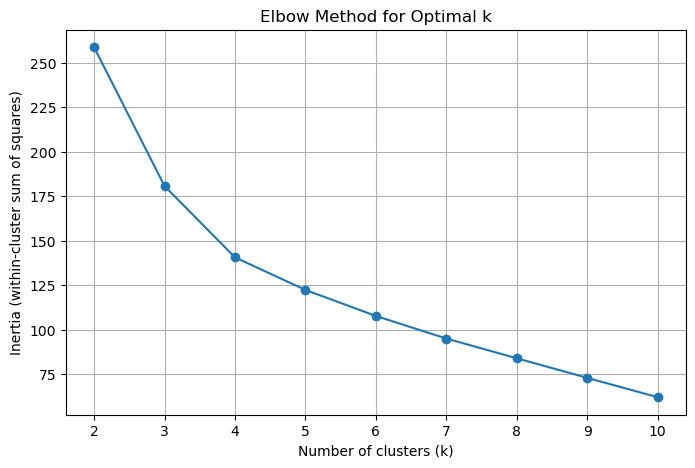

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with M

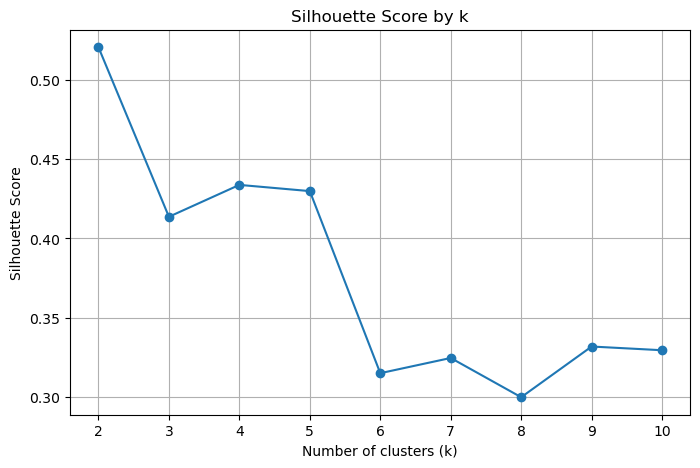

k=2: silhouette=0.5205
k=3: silhouette=0.4137
k=4: silhouette=0.4338
k=5: silhouette=0.4298
k=6: silhouette=0.3152
k=7: silhouette=0.3247
k=8: silhouette=0.3000
k=9: silhouette=0.3319
k=10: silhouette=0.3296


In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.grid(True)
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.4f}")

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
feature_table['cluster'] = kmeans.fit_predict(scaled_features)

feature_table['cluster'].value_counts().sort_index()

c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


cluster
0    64
1    22
2     4
3    13
Name: count, dtype: int64

In [33]:
cluster_profile = feature_table.groupby('cluster')[['txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']].mean()
cluster_profile['n_areas'] = feature_table['cluster'].value_counts().sort_index()
cluster_profile

,txn_count,avg_deal_size,growth_b_slope,volatility_cv,n_areas
cluster,,,,,
0,7727.015625,3.131120e+06,52842.001398,0.495099,64
1,469.181818,1.115185e+07,319482.548581,0.499034,22
2,88431.500000,1.805581e+06,-166150.683918,0.915167,4
3,23808.692308,1.948583e+06,-568388.422325,1.475462,13


In [34]:
feature_table[feature_table['cluster'] == 2][['area_name', 'txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']].sort_values('txn_count', ascending=False)

,area_name,txn_count,avg_deal_size,growth_b_slope,volatility_cv
73,Marsa Dubai,104085,2.423102e+06,-443164.446091,1.515079
56,Business Bay,92225,1.840739e+06,22942.967527,0.181309
6,Al Barsha South Fourth,86337,1.230568e+06,-230538.556674,1.565519
41,Al Thanyah Fifth,71079,1.727915e+06,-13842.700435,0.398760


In [35]:
feature_table[feature_table['cluster'] == 3][['area_name', 'txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']].sort_values('txn_count', ascending=False)

,area_name,txn_count,avg_deal_size,growth_b_slope,volatility_cv
55,Burj Khalifa,54086,3.392181e+06,-5.449670e+05,1.394396
50,Al Warsan First,50863,6.051298e+05,-1.077049e+05,1.709243
16,Al Hebiah Fourth,36598,1.808510e+06,-4.085148e+05,1.574925
28,Al Merkadh,34207,2.228579e+06,-9.550823e+05,1.107200
81,Nadd Hessa,26650,9.685019e+05,-2.352373e+05,1.847053
9,Al Barshaa South Third,22820,1.124405e+06,-3.574158e+05,1.670957
43,Al Thanyah Third,20913,2.025157e+06,-3.294300e+05,1.122844
53,Al Yelayiss 2,18083,1.249136e+06,-1.207283e+06,2.387195
5,Al Barsha South Fifth,17711,1.417492e+06,-2.496873e+05,1.406978
19,Al Jadaf,11248,3.461260e+06,-8.388371e+05,1.014068


In [36]:
feature_table[feature_table['cluster'] == 1][['area_name', 'txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']].sort_values('avg_deal_size', ascending=False)

,area_name,txn_count,avg_deal_size,growth_b_slope,volatility_cv
62,Island 2,782,1.972617e+07,1.635676e+05,0.373383
68,Jumeirah Second,546,1.770362e+07,6.593763e+05,0.672120
65,Jabal Ali Industrial First,724,1.693188e+07,-3.498712e+05,0.362522
33,Al Nahda Second,324,1.662215e+07,1.199513e+06,0.523377
72,Mankhool,269,1.507839e+07,3.117831e+05,0.442434
88,Saih Shuaib 4,500,1.439768e+07,-3.440632e+05,0.253479
31,Al Murqabat,258,1.220019e+07,-6.907403e+04,0.439531
3,Al Barsha First,1078,1.158010e+07,5.254135e+04,0.554613
48,Al Warqa First,435,1.134912e+07,5.142503e+05,0.438834
92,Um Suqaim First,459,1.102901e+07,6.612929e+05,0.662984


In [37]:
feature_table[feature_table['cluster'] == 0][['area_name', 'txn_count', 'avg_deal_size', 'growth_b_slope', 'volatility_cv']].sort_values('avg_deal_size', ascending=False)

,area_name,txn_count,avg_deal_size,growth_b_slope,volatility_cv
63,Jabal Ali,1332,9.039783e+06,-350299.873817,0.331531
79,Nad Al Shiba,1017,7.594221e+06,-424933.777955,0.459310
67,Jumeirah First,4218,5.768287e+06,126218.715589,0.440060
10,Al Dhagaya,249,5.683910e+06,288501.625935,0.553055
2,Al Baraha,231,5.457896e+06,121139.360936,0.599459
...,...,...,...,...,...
71,Madinat Hind 4,11523,1.495995e+06,121653.236243,0.571227
95,Wadi Al Safa 2,12212,1.488487e+06,-16341.323195,0.503080
66,Jabal Ali Industrial Second,2916,1.429305e+06,-160242.975396,0.726935
45,Al Twar Fourth,242,1.244748e+06,94041.525308,0.899425


In [38]:

import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("postgresql://postgres:@localhost:5433/real_estate_data")

# --- 1. area_cluster_assignments ---
area_cluster_assignments = feature_table[[
    "area_name", "cluster", "txn_count", "avg_deal_size",
    "growth_b_slope", "volatility_cv", "total_value"
]].copy()

assert len(area_cluster_assignments) == 103, f"Expected 103 rows, got {len(area_cluster_assignments)}"

area_cluster_assignments.to_sql(
    "area_cluster_assignments",
    engine,
    if_exists="replace",
    index=False
)

# --- 2. cluster_profile_summary ---
cluster_names = {
    0: "Established Mid-Market Areas",
    1: "Premium Growth Areas",
    2: "High-Turnover, Declining-Value Areas (n=4)",
    3: "High-Volatility Declining Areas"
}

cluster_profile_summary = (
    feature_table
    .groupby("cluster")
    .agg(
        n_areas=("area_name", "count"),
        avg_txn_count=("txn_count", "mean"),
        avg_deal_size=("avg_deal_size", "mean"),
        avg_growth_b_slope=("growth_b_slope", "mean"),
        avg_volatility_cv=("volatility_cv", "mean"),
    )
    .reset_index()
)

cluster_profile_summary["cluster_name"] = cluster_profile_summary["cluster"].map(cluster_names)

cluster_profile_summary = cluster_profile_summary[[
    "cluster", "cluster_name", "n_areas",
    "avg_txn_count", "avg_deal_size", "avg_growth_b_slope", "avg_volatility_cv"
]]

assert len(cluster_profile_summary) == 4, f"Expected 4 rows, got {len(cluster_profile_summary)}"
assert list(cluster_profile_summary["n_areas"]) == [64, 22, 4, 13], "n_areas mismatch vs expected distribution"

#cluster_profile_summary.to_sql(
    #"cluster_profile_summary",
    #engine,
    #if_exists="replace",
    #index=False
#)

#print("Pushed successfully.")
#print(area_cluster_assignments.shape, cluster_profile_summary.shape)

In [39]:
cluster_profile_summary

,cluster,cluster_name,n_areas,avg_txn_count,avg_deal_size,avg_growth_b_slope,avg_volatility_cv
0,0,Established Mid-Market Areas,64,7727.015625,3.131120e+06,52842.001398,0.495099
1,1,Premium Growth Areas,22,469.181818,1.115185e+07,319482.548581,0.499034
2,2,"High-Turnover, Declining-Value Areas (n=4)",4,88431.500000,1.805581e+06,-166150.683918,0.915167
3,3,High-Volatility Declining Areas,13,23808.692308,1.948583e+06,-568388.422325,1.475462


In [40]:
from sklearn.preprocessing import MinMaxScaler

radar = cluster_profile_summary.copy()

scaler = MinMaxScaler()

# Positive metrics
radar[
    [
        "growth_score",
        "deal_size_score",
        "liquidity_score",
        "volume_score"
    ]
] = scaler.fit_transform(
    radar[
        [
            "avg_growth_b_slope",
            "avg_deal_size",
            "avg_txn_count",
            "n_areas"
        ]
    ]
) * 100

In [41]:
radar["stability_score"] = (
    100 -
    scaler.fit_transform(
        radar[["avg_volatility_cv"]]
    ).flatten() * 100
)

In [42]:
radar_final = radar.melt(
    id_vars=[
        "cluster_name"
    ],
    value_vars=[
        "growth_score",
        "deal_size_score",
        "liquidity_score",
        "stability_score",
        "volume_score"
    ],
    var_name="Metric",
    value_name="Score"
)

In [43]:
radar_final["Metric"] = radar_final["Metric"].replace({
    "growth_score":"Growth",
    "deal_size_score":"Deal Size",
    "liquidity_score":"Liquidity",
    "stability_score":"Stability",
    "volume_score":"Volume"
})

In [44]:
#radar_final.to_sql(
    #"cluster_radar_scores",
    #engine,
    #if_exists="replace",
    #index=False
#)

In [45]:
from sklearn.preprocessing import MinMaxScaler

radar = cluster_profile_summary.copy()

# total transaction volume per cluster = avg_txn_count * n_areas
radar["total_txn_volume"] = radar["avg_txn_count"] * radar["n_areas"]

scaler = MinMaxScaler()

radar[
    [
        "growth_score",
        "deal_size_score",
        "liquidity_score",
        "volume_score"
    ]
] = scaler.fit_transform(
    radar[
        [
            "avg_growth_b_slope",
            "avg_deal_size",
            "avg_txn_count",
            "total_txn_volume"
        ]
    ]
) * 100

# stability stays as-is, inverted
radar["stability_score"] = (
    100 - scaler.fit_transform(radar[["avg_volatility_cv"]]).flatten() * 100
) 

In [46]:
# reshape wide -> long (one row per cluster x metric)
radar_final = radar.melt(
    id_vars=["cluster", "cluster_name", "n_areas"],
    value_vars=[
        "growth_score",
        "deal_size_score",
        "liquidity_score",
        "stability_score",
        "volume_score"
    ],
    var_name="Metric",
    value_name="Score"
)

# rename metric labels for display
radar_final["Metric"] = radar_final["Metric"].replace({
    "growth_score": "Growth",
    "deal_size_score": "Deal Size",
    "liquidity_score": "Liquidity",
    "stability_score": "Stability",
    "volume_score": "Volume"
})

# sanity checks before pushing
assert len(radar_final) == 20, f"Expected 20 rows (4 clusters x 5 metrics), got {len(radar_final)}"

# direction checks
c1_growth = radar_final.query("cluster == 1 and Metric == 'Growth'")["Score"].iloc[0]
c1_dealsize = radar_final.query("cluster == 1 and Metric == 'Deal Size'")["Score"].iloc[0]
c3_stability = radar_final.query("cluster == 3 and Metric == 'Stability'")["Score"].iloc[0]

print("Cluster 1 growth score (expect 100):", c1_growth)
print("Cluster 1 deal size score (expect 100):", c1_dealsize)
print("Cluster 3 stability score (expect 0):", c3_stability)

# push to Postgres
#radar_final.to_sql(
    #"cluster_radar_scores",
    #engine,
    #if_exists="replace",
    #index=False
#)

#print("Pushed successfully.")
#print(radar_final.shape)

Cluster 1 growth score (expect 100): 100.0
Cluster 1 deal size score (expect 100): 99.99999999999997
Cluster 3 stability score (expect 0): 0.0


In [47]:
import pandas as pd

lat_and_long = pd.read_sql("SELECT area_name, latitude, longitude FROM area_coordinates", engine)

In [48]:
from sklearn.cluster import KMeans

kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_k3.fit_predict(scaled_df)

# check where the 4 known Cluster 2 areas landed
check_areas = ['Marsa Dubai', 'Business Bay', 'Al Barsha South Fourth', 'Al Thanyah Fifth']
feature_table_k3 = feature_table.copy()
feature_table_k3['cluster_k3'] = labels_k3
print(feature_table_k3[feature_table_k3['area_name'].isin(check_areas)][['area_name', 'cluster_k3']])

                 area_name  cluster_k3
6   Al Barsha South Fourth           1
41        Al Thanyah Fifth           0
56            Business Bay           0
73             Marsa Dubai           1


c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [49]:
print(feature_table_k3.groupby('cluster_k3').size())
print(feature_table_k3.groupby('cluster_k3')[['txn_count','avg_deal_size','growth_b_slope','volatility_cv']].mean())

cluster_k3
0    66
1    15
2    22
dtype: int64
               txn_count  avg_deal_size  growth_b_slope  volatility_cv
cluster_k3                                                            
0            9967.166667   3.090308e+06    51378.611463       0.488884
1           33329.000000   1.932350e+06  -537516.832866       1.484107
2             469.181818   1.115185e+07   319482.548581       0.499034
